In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL3Npc3NpeWFuZy9EL1RyYWRlX09TL3F1YW50LWZvci1iZWdpbm5lcnMvaG9tZXdvcms='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/importlib/_bootstrap.py": 1784012591.3310614, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/importlib/_bootstrap_external.py": 1784012591.331289, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/zipimport.py": 1784012591.7612646, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/codecs.py": 1784012590.9808702, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/encodings/aliases.py": 1784012591.0006135, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/encodings/__init__.py": 1784012590.9992645, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/encodings/utf_8.py": 1784012591.0316708, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none

In [2]:
# ========== 环境准备 ==========
import warnings

warnings.filterwarnings("ignore")  # 忽略次要警告，输出更干净

import numpy as np  # 数值计算
import pandas as pd  # 表格数据处理
import matplotlib.pyplot as plt  # 绘图
import akshare as ak
from datetime import datetime, timedelta  # 添加 timedelta 用于日期计算

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

plt.rcParams["axes.unicode_minus"] = False  # 让坐标轴上的负号正常显示
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "sans-serif"]  # 新增这一行

# 策略参数
TICKER = 'AAPL'      # 策略交易哪只股票
BENCHMARK = 'SPY'    # 大盘对比用标普500 ETF
PERIOD = '2y'        # 回测样本长度（用于注释）

print('环境就绪 ✓')                       # 提示：环境加载完成

环境就绪 ✓


In [3]:
# ========== 第1步：下载数据并算双均线 ==========
# 解析 PERIOD（如 '2y'）为天数（2年约730天）
days = int(PERIOD[0]) * 365 if PERIOD.endswith('y') else 365  # 简单解析
end_date = datetime.now()
start_date = end_date - timedelta(days=days + 30)  # 多取一些天以防不足

# 使用 akshare 获取美股日线数据
raw = ak.stock_us_daily(symbol=TICKER, adjust='qfq')
raw['date'] = pd.to_datetime(raw['date'])
raw = raw.set_index('date').sort_index()
# 截取指定时间段
raw = raw[(raw.index >= start_date) & (raw.index <= end_date)]
# 列名统一为首字母大写
raw.columns = [col.capitalize() for col in raw.columns]
df = raw[['Close']].dropna().copy()

df['MA5'] = df['Close'].rolling(5).mean()  # 滚动窗口计算
df['MA20'] = df['Close'].rolling(20).mean()  # 滚动窗口计算
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 收盘算出的「理论信号」

# ========== 第2步：信号推迟一天，避免用未来数据 ==========
df['position'] = df['signal'].shift(1).fillna(0).astype(int)  # 今天实际仓位

# ========== 第3步：标记买入、卖出日 ==========
df['position_change'] = df['position'].diff().fillna(0)  # 仓位变化：0→1买，1→0卖
df['action'] = ''  # 初始化动作列
df.loc[df['position_change'] > 0, 'action'] = 'Buy'  # 标记买入或卖出文字
df.loc[df['position_change'] < 0, 'action'] = 'Sell'  # 标记买入或卖出文字

trades = df[df['action'] != '']  # 所有调仓日
print(f'Stock {TICKER}, total {len(df)} trading days')  # 打印统计结果
print(f'Simulated trades: Buy {(df["action"]=="Buy").sum()} times, Sell {(df["action"]=="Sell").sum()} times')  # 打印分隔线或结论
print('\nRecent trades:')  # 打印输出
display(trades[['Close', 'MA5', 'MA20', 'position', 'action']].tail(6))  # 在 Notebook 中美观显示表格

Stock AAPL, total 520 trading days
Simulated trades: Buy 17 times, Sell 16 times

Recent trades:


,Close,MA5,MA20,position,action
date,,,,,
2026-02-20,264.31,261.564,264.6185,0,Sell
2026-02-26,272.68,269.746,268.0375,1,Buy
2026-03-04,262.25,265.354,267.9855,0,Sell
2026-04-07,253.23,255.270,252.8915,1,Buy
2026-06-10,291.58,300.448,304.3970,0,Sell
2026-07-07,310.66,303.138,295.0400,1,Buy


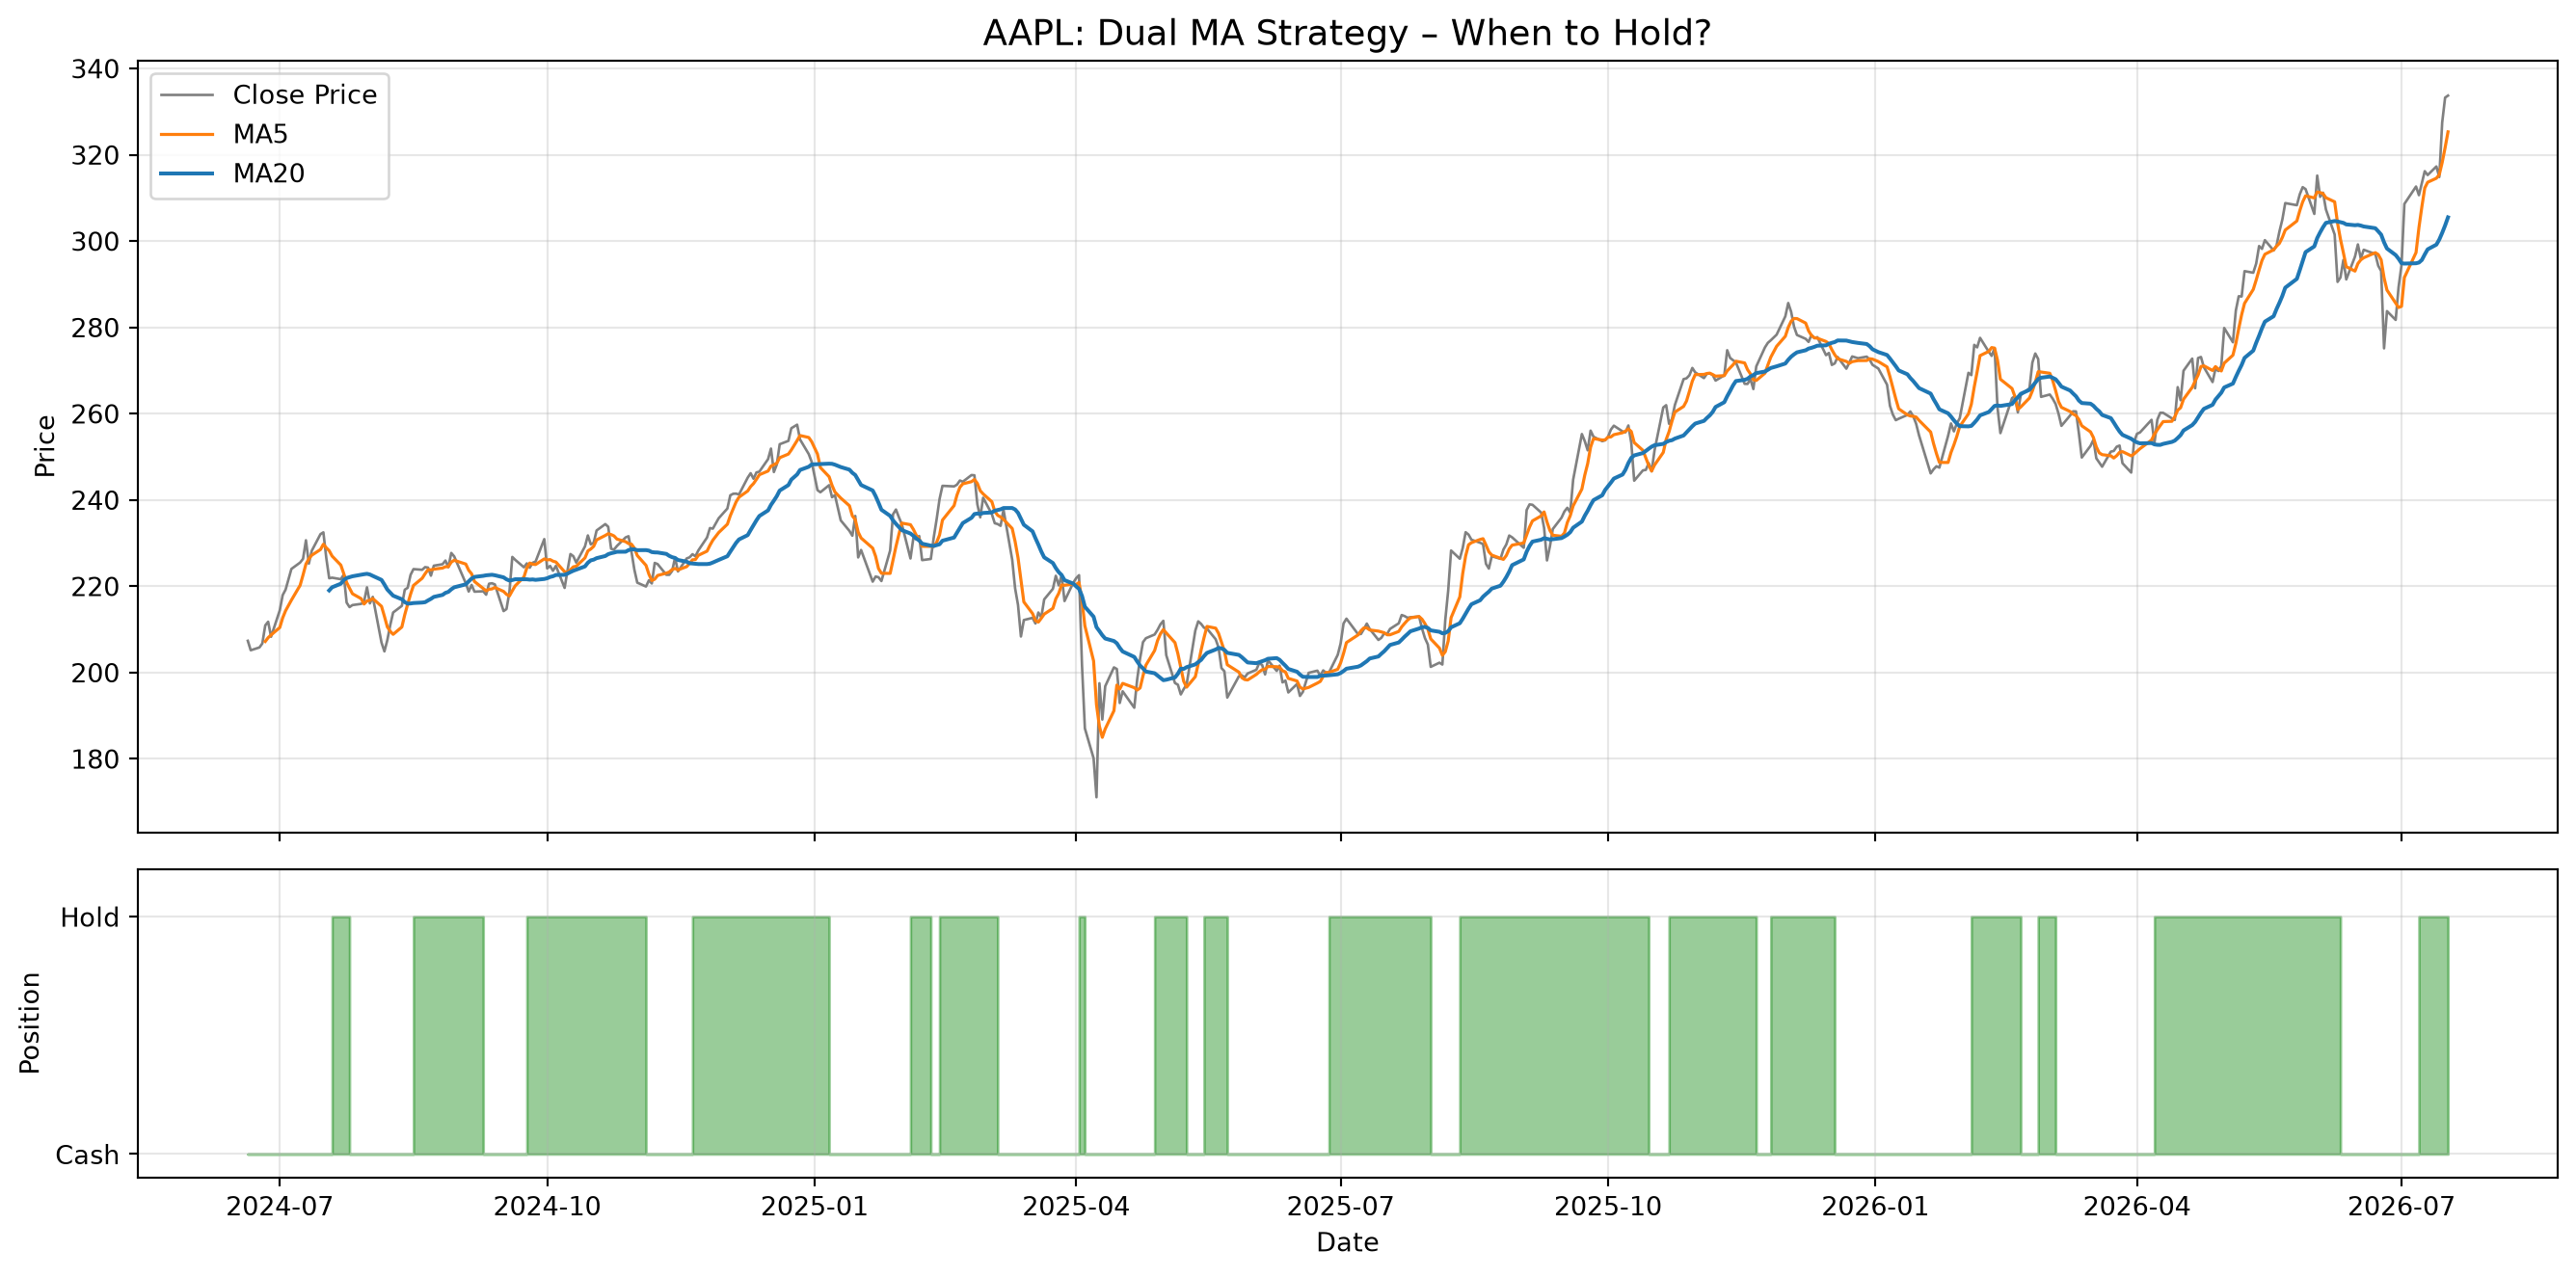

Green area = holding (after buy, before sell) | Blank = cash


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,  # 创建子图
                         gridspec_kw={'height_ratios': [2.5, 1]})  # 子图高度比例

axes[0].plot(df.index, df['Close'], color='gray', linewidth=1, label='Close Price')  # 上图：画折线
axes[0].plot(df.index, df['MA5'], color='tab:orange', linewidth=1.2, label='MA5')  # 上图：画折线
axes[0].plot(df.index, df['MA20'], color='tab:blue', linewidth=1.5, label='MA20')  # 上图：画折线
axes[0].set_ylabel('Price')  # 设置上图纵轴
axes[0].set_title(f'{TICKER}: Dual MA Strategy – When to Hold?', fontsize=14)  # 设置上图标题
axes[0].legend(loc='upper left')  # 显示上图图例
axes[0].grid(True, alpha=0.3)  # 上图显示网格

axes[1].fill_between(df.index, 0, df['position'], step='post', alpha=0.4, color='green')  # 实际持仓（信号推迟一天）
axes[1].set_ylim(-0.1, 1.2)  # 执行本行代码
axes[1].set_yticks([0, 1])  # 执行本行代码
axes[1].set_yticklabels(['Cash', 'Hold'])  # 执行本行代码
axes[1].set_xlabel('Date')  # 设置下图横轴（日期）
axes[1].set_ylabel('Position')  # 设置下图纵轴
axes[1].grid(True, alpha=0.3)  # 下图显示网格

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

print('Green area = holding (after buy, before sell) | Blank = cash')  # 解读三色区域含义

In [5]:
# ========== 算日收益率 ==========
df['ret'] = df['Close'].pct_change().fillna(0)  # 股票本身每天涨跌

# ========== 策略收益：只有持仓日才吃到涨跌 ==========
df['strategy_ret'] = df['position'] * df['ret']  # 实际持仓（信号推迟一天）

# ========== 基准1：买入持有（一直满仓）==========
df['buyhold_ret'] = df['ret']  # 股票日收益率

# ========== 基准2：同期持有大盘 SPY（使用 akshare）==========
# 获取基准数据（与股票数据同区间）
bench_end = df.index[-1]
bench_start = df.index[0]
bench_raw = ak.stock_us_daily(symbol=BENCHMARK, adjust='qfq')
bench_raw['date'] = pd.to_datetime(bench_raw['date'])
bench_raw = bench_raw.set_index('date').sort_index()
bench_raw = bench_raw[(bench_raw.index >= bench_start) & (bench_raw.index <= bench_end)]
bench_raw.columns = [col.capitalize() for col in bench_raw.columns]
spy = bench_raw[['Close']].rename(columns={'Close': 'SPY_Close'})

df = df.join(spy, how='inner')  # 按日期对齐，只保留两边都有数据的行
df['market_ret'] = df['SPY_Close'].pct_change().fillna(0)  # 计算日收益率（今天相对昨天）

# ========== 累计净值：从 1 元钱出发连乘 ==========
df['nav_strategy'] = (1 + df['strategy_ret']).cumprod()  # 连乘得到累计净值/价格
df['nav_buyhold'] = (1 + df['buyhold_ret']).cumprod()  # 连乘得到累计净值/价格
df['nav_market'] = (1 + df['market_ret']).cumprod()  # 连乘得到累计净值/价格

total_strategy = df['nav_strategy'].iloc[-1] - 1  # 策略累计收益
total_buyhold = df['nav_buyhold'].iloc[-1] - 1  # 买入持有累计收益
total_market = df['nav_market'].iloc[-1] - 1  # 大盘累计收益

print('=== Sample period cumulative returns (excl. fees, for learning only) ===')  # 打印分隔线或结论
print(f'  Dual MA Strategy ({TICKER}): {total_strategy:+.2%}')  # 格式化打印
print(f'  Buy & Hold ({TICKER}):        {total_buyhold:+.2%}')  # 格式化打印
print(f'  Buy & Hold ({BENCHMARK} market): {total_market:+.2%}')  # 格式化打印

=== Sample period cumulative returns (excl. fees, for learning only) ===
  Dual MA Strategy (AAPL): -2.66%
  Buy & Hold (AAPL):        +60.94%
  Buy & Hold (SPY market): +40.10%


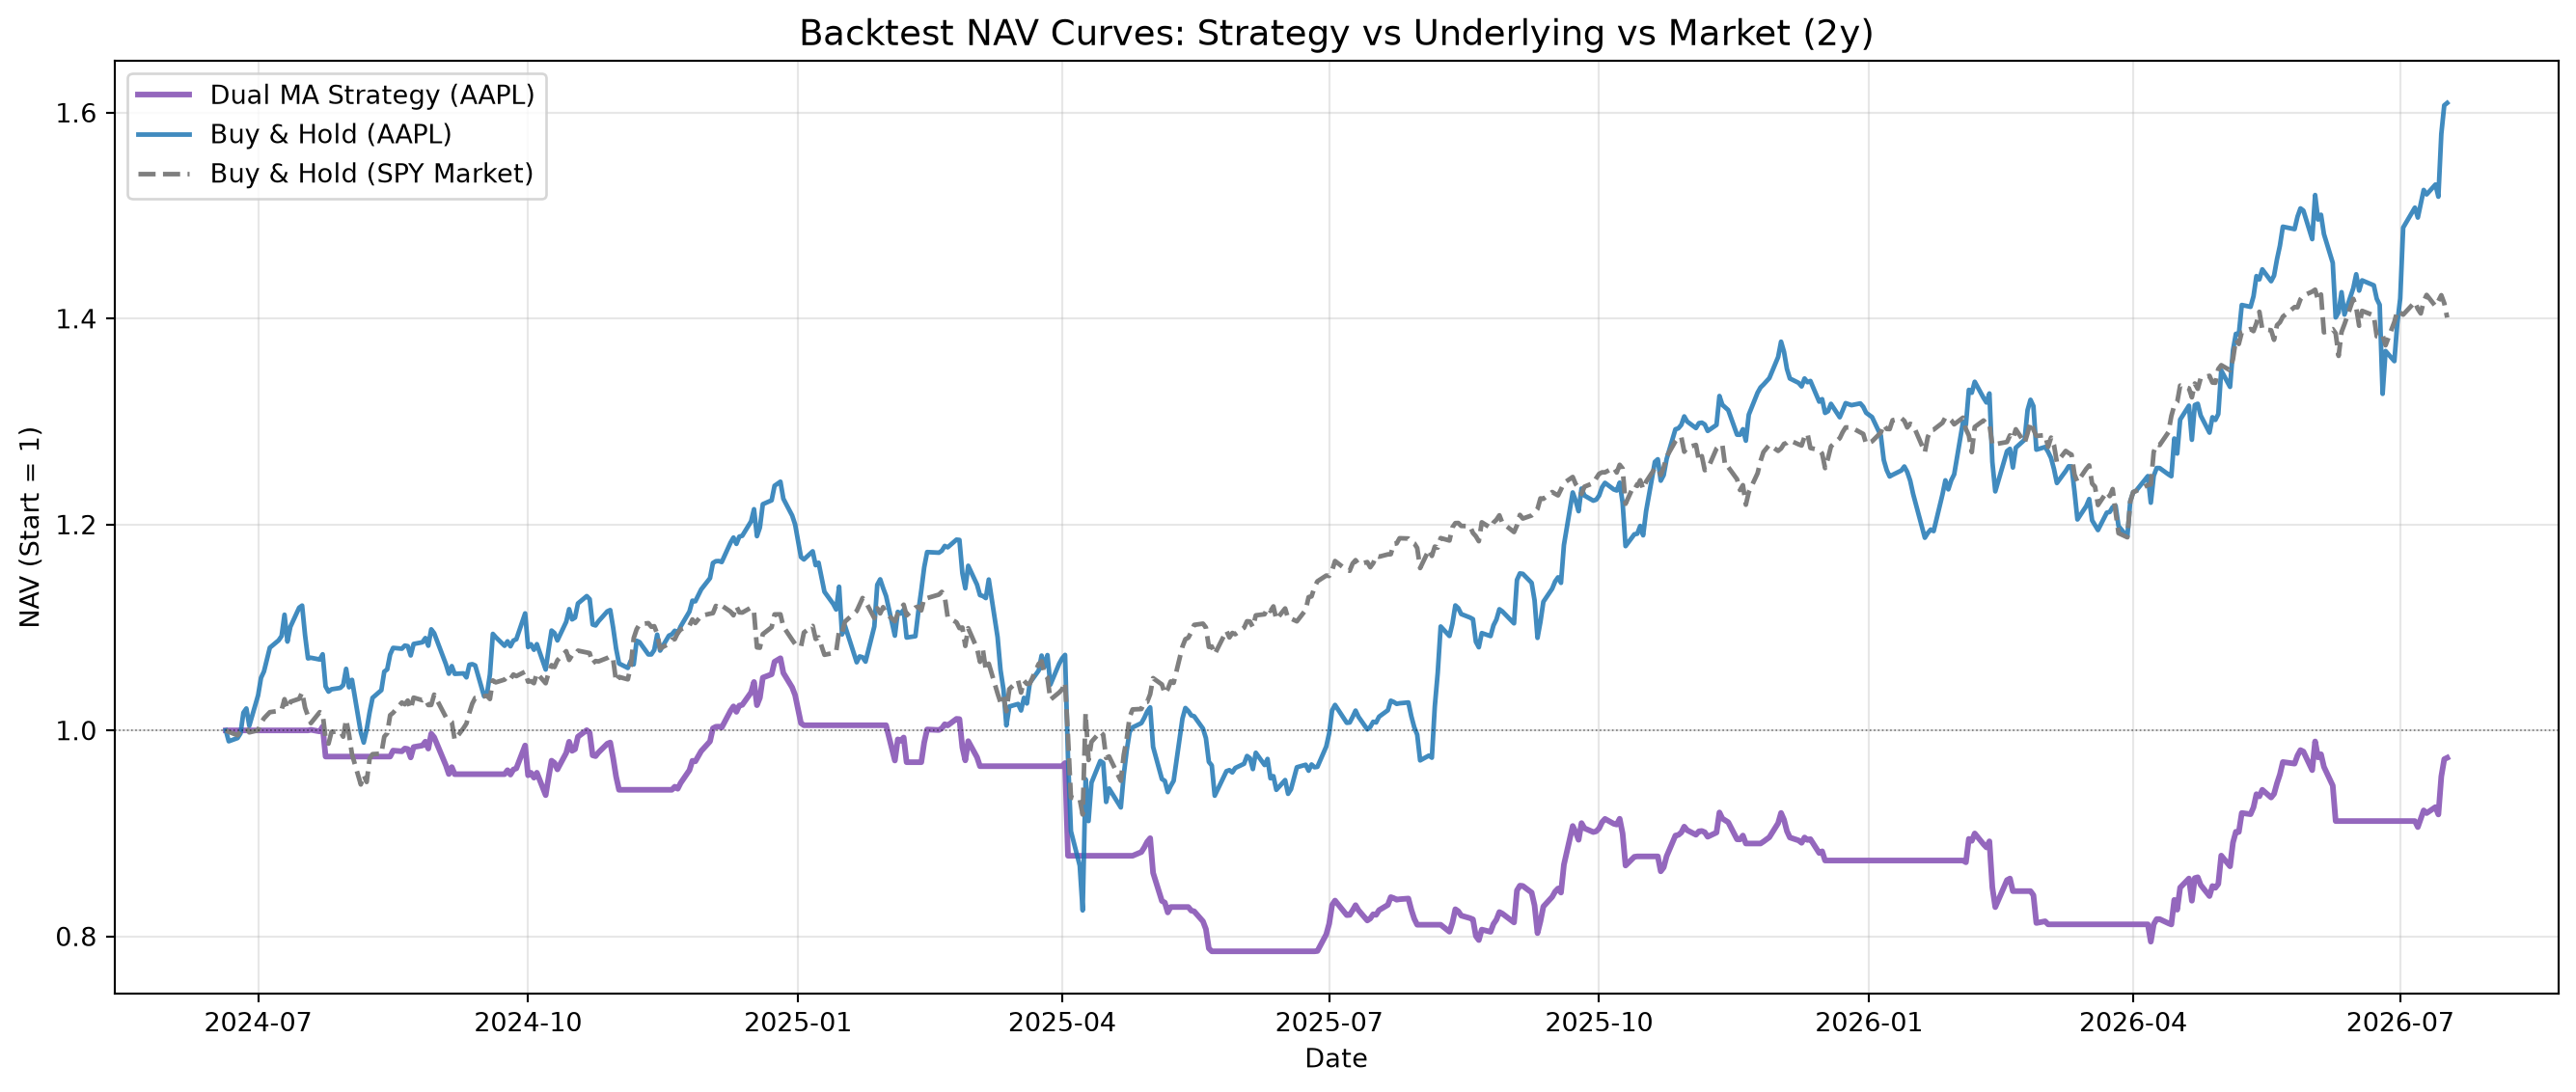

In [6]:
# ========== 三条净值曲线对比（回测高潮图）==========
fig, ax = plt.subplots(figsize=(14, 6))  # 创建子图

ax.plot(df.index, df['nav_strategy'], linewidth=2.2, color='tab:purple',  # 在子图上画折线
        label=f'Dual MA Strategy ({TICKER})')  # 图例文字
ax.plot(df.index, df['nav_buyhold'], linewidth=1.8, color='tab:blue', alpha=0.85,  # 在子图上画折线
        label=f'Buy & Hold ({TICKER})')  # 图例文字
ax.plot(df.index, df['nav_market'], linewidth=1.8, color='tab:gray', linestyle='--',  # 在子图上画折线
        label=f'Buy & Hold ({BENCHMARK} Market)')  # 图例文字

ax.axhline(1.0, color='black', linewidth=0.6, linestyle=':', alpha=0.5)  # 画水平参考线
ax.set_title(f'Backtest NAV Curves: Strategy vs Underlying vs Market ({PERIOD})', fontsize=14)  # 设置子图标题
ax.set_xlabel('Date')  # 设置子图横轴
ax.set_ylabel('NAV (Start = 1)')  # 设置子图纵轴
ax.legend(loc='upper left')  # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

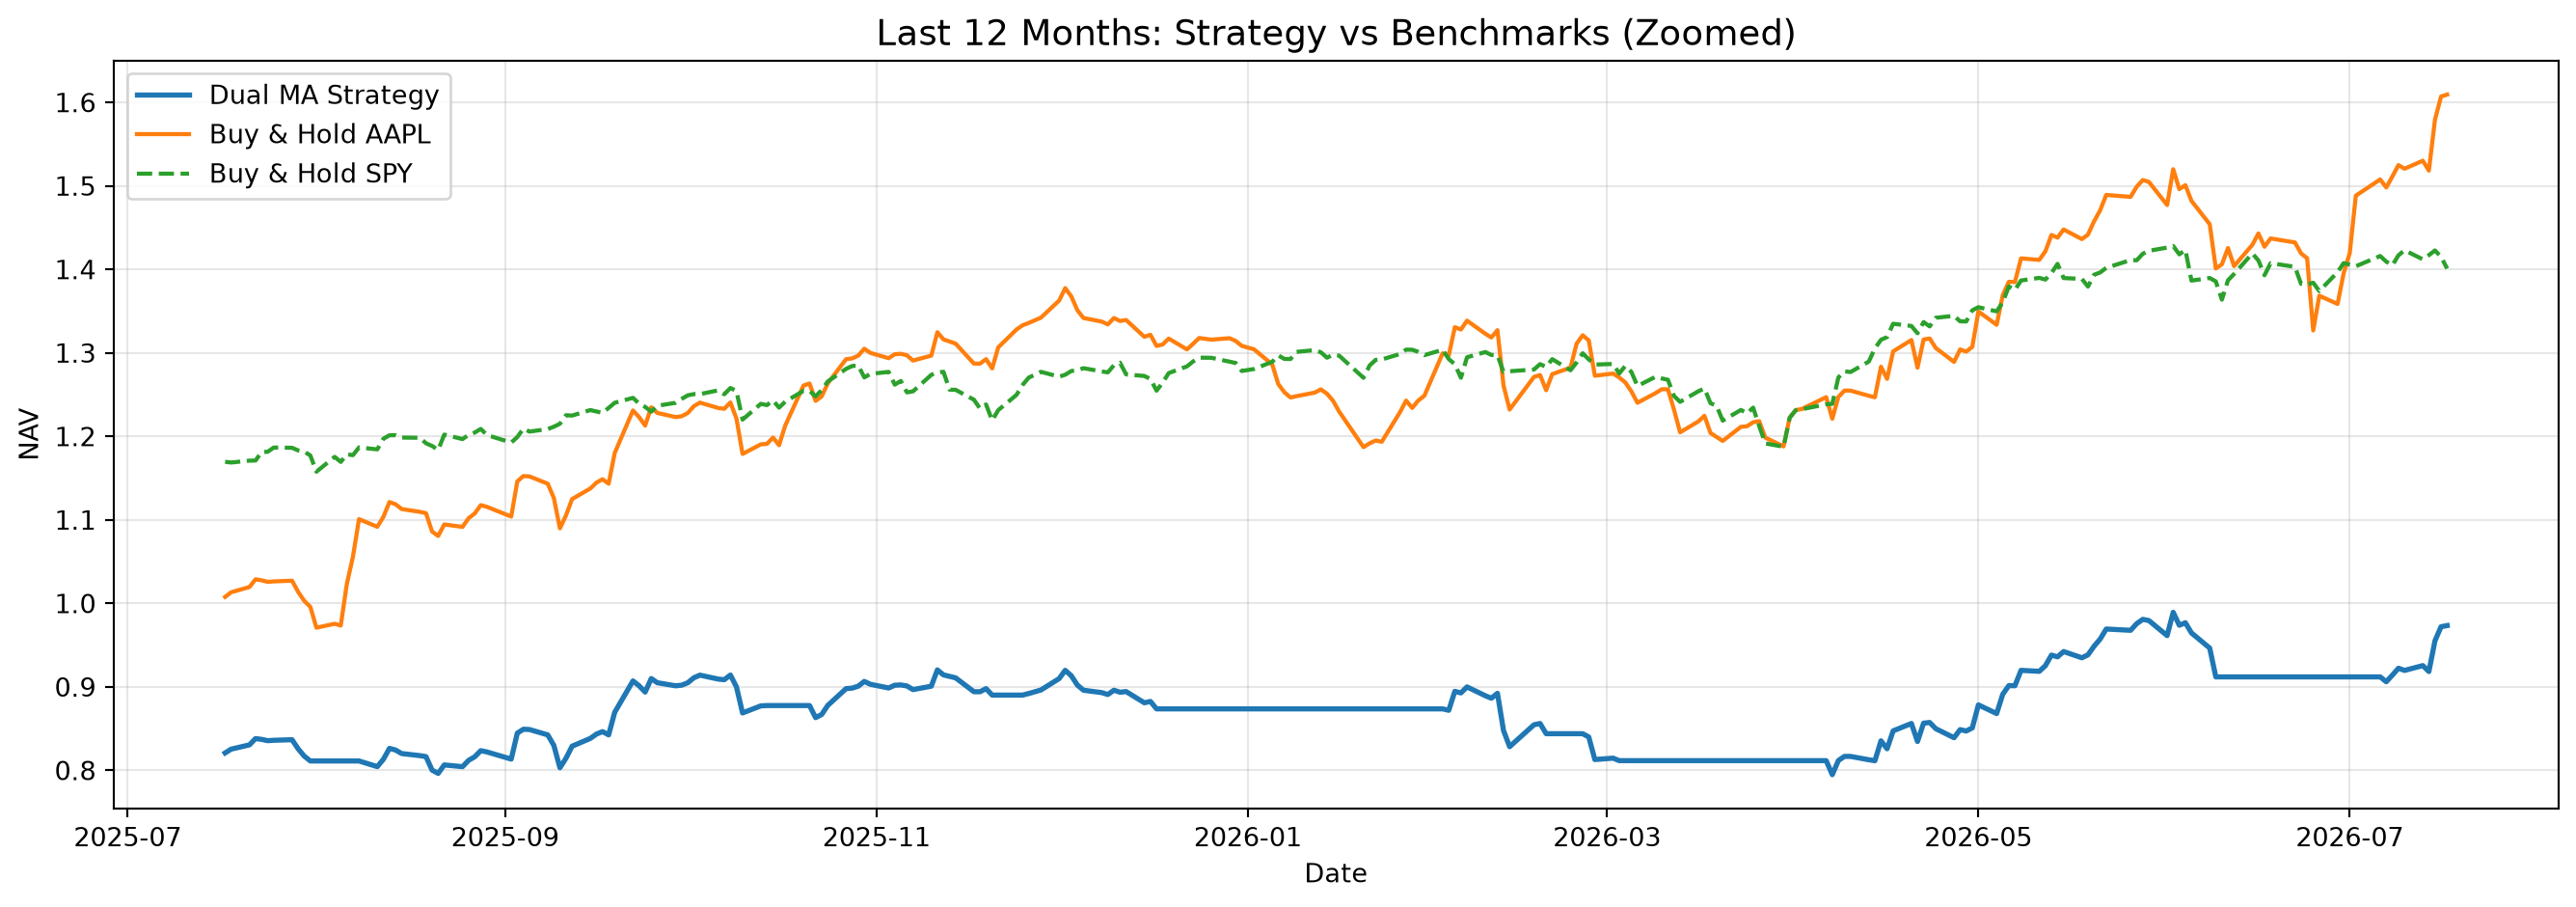

In [7]:
# ========== 近12个月局部放大 ==========
# 使用日期偏移量切片，兼容所有pandas版本
cutoff = df.index[-1] - pd.DateOffset(months=12)
recent = df[df.index >= cutoff] if len(df) > 200 else df.tail(200)  # 取最后约12个月

plt.figure(figsize=(14, 5))  # 创建画布
plt.plot(recent.index, recent['nav_strategy'], linewidth=2, label='Dual MA Strategy')  # 画折线图
plt.plot(recent.index, recent['nav_buyhold'], linewidth=1.6, label=f'Buy & Hold {TICKER}')  # 画折线图
plt.plot(recent.index, recent['nav_market'], linewidth=1.6, linestyle='--', label=f'Buy & Hold {BENCHMARK}')  # 画折线图
plt.title('Last 12 Months: Strategy vs Benchmarks (Zoomed)', fontsize=14)  # 设置图标题
plt.xlabel('Date')  # 设置横轴标签
plt.ylabel('NAV')  # 设置纵轴标签
plt.legend()  # 显示图例
plt.grid(True, alpha=0.3)  # 显示网格线
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

In [8]:
# ========== 统计胜率：一轮「买入→卖出」算一局 ==========
wins, losses = 0, 0       # 赢、输次数
entry_price = None        # 记住买入价
records = []              # 存每轮结果

for date, row in df.iterrows():  # 按天遍历整张表
    if row['action'] == 'Buy':  # 遇到买入日
        entry_price = row['Close']   # 记录买入当天的收盘价
    elif row['action'] == 'Sell' and entry_price is not None:  # 遇到卖出且之前买过
        pnl = row['Close'] / entry_price - 1   # 本轮收益率
        if pnl > 0:  # 赚钱算赢
            wins += 1                    # 赢局计数 +1
            outcome = 'Win'                 # 标记本局结果为赢
        else:  # 亏钱算输
            losses += 1                # 输局计数 +1
            outcome = 'Lose'                 # 标记本局结果为输
        records.append({  # 记录本轮交易结果
            'Sell Date': date.strftime('%Y-%m-%d'),  # 卖出日期
            'Buy Price': round(entry_price, 2),  # 买入价格
            'Sell Price': round(row['Close'], 2),  # 卖出价格
            'Round Return': f'{pnl:+.2%}',  # 本轮收益率
            'Result': outcome,  # 赢或输
        })  # 执行本行代码
        entry_price = None   # 本轮结束，清空买入价

total_rounds = wins + losses              # 完整买卖回合总数
win_rate = wins / total_rounds if total_rounds > 0 else np.nan  # 胜率

print(f'Total complete rounds: {total_rounds}')  # 打印回合总数
print(f'  Wins: {wins}')  # 打印赢的次数
print(f'  Losses: {losses}')  # 打印输的次数
print(f'  Win Rate: {win_rate:.1%}' if total_rounds > 0 else '  No complete round yet')  # 打印胜率

if records:  # 有交易记录则展示
    display(pd.DataFrame(records).tail(8))  # 在 Notebook 中美观显示表格

Total complete rounds: 16
  Wins: 5
  Losses: 11
  Win Rate: 31.2%


,Sell Date,Buy Price,Sell Price,Round Return,Result
8,2025-05-23,210.40,194.22,-7.69%,Lose
9,2025-08-01,200.03,201.33,+0.65%,Win
10,2025-10-15,226.39,248.55,+9.79%,Win
11,2025-11-21,257.66,270.96,+5.16%,Win
12,2025-12-18,277.02,271.66,-1.93%,Lose
13,2026-02-20,268.95,264.31,-1.73%,Lose
14,2026-03-04,272.68,262.25,-3.82%,Lose
15,2026-06-10,253.23,291.58,+15.14%,Win


=== Maximum Drawdown (deepest drop from peak during sample period) ===
  Dual MA Strategy: -26.60%
  Buy & Hold (AAPL): -33.54%


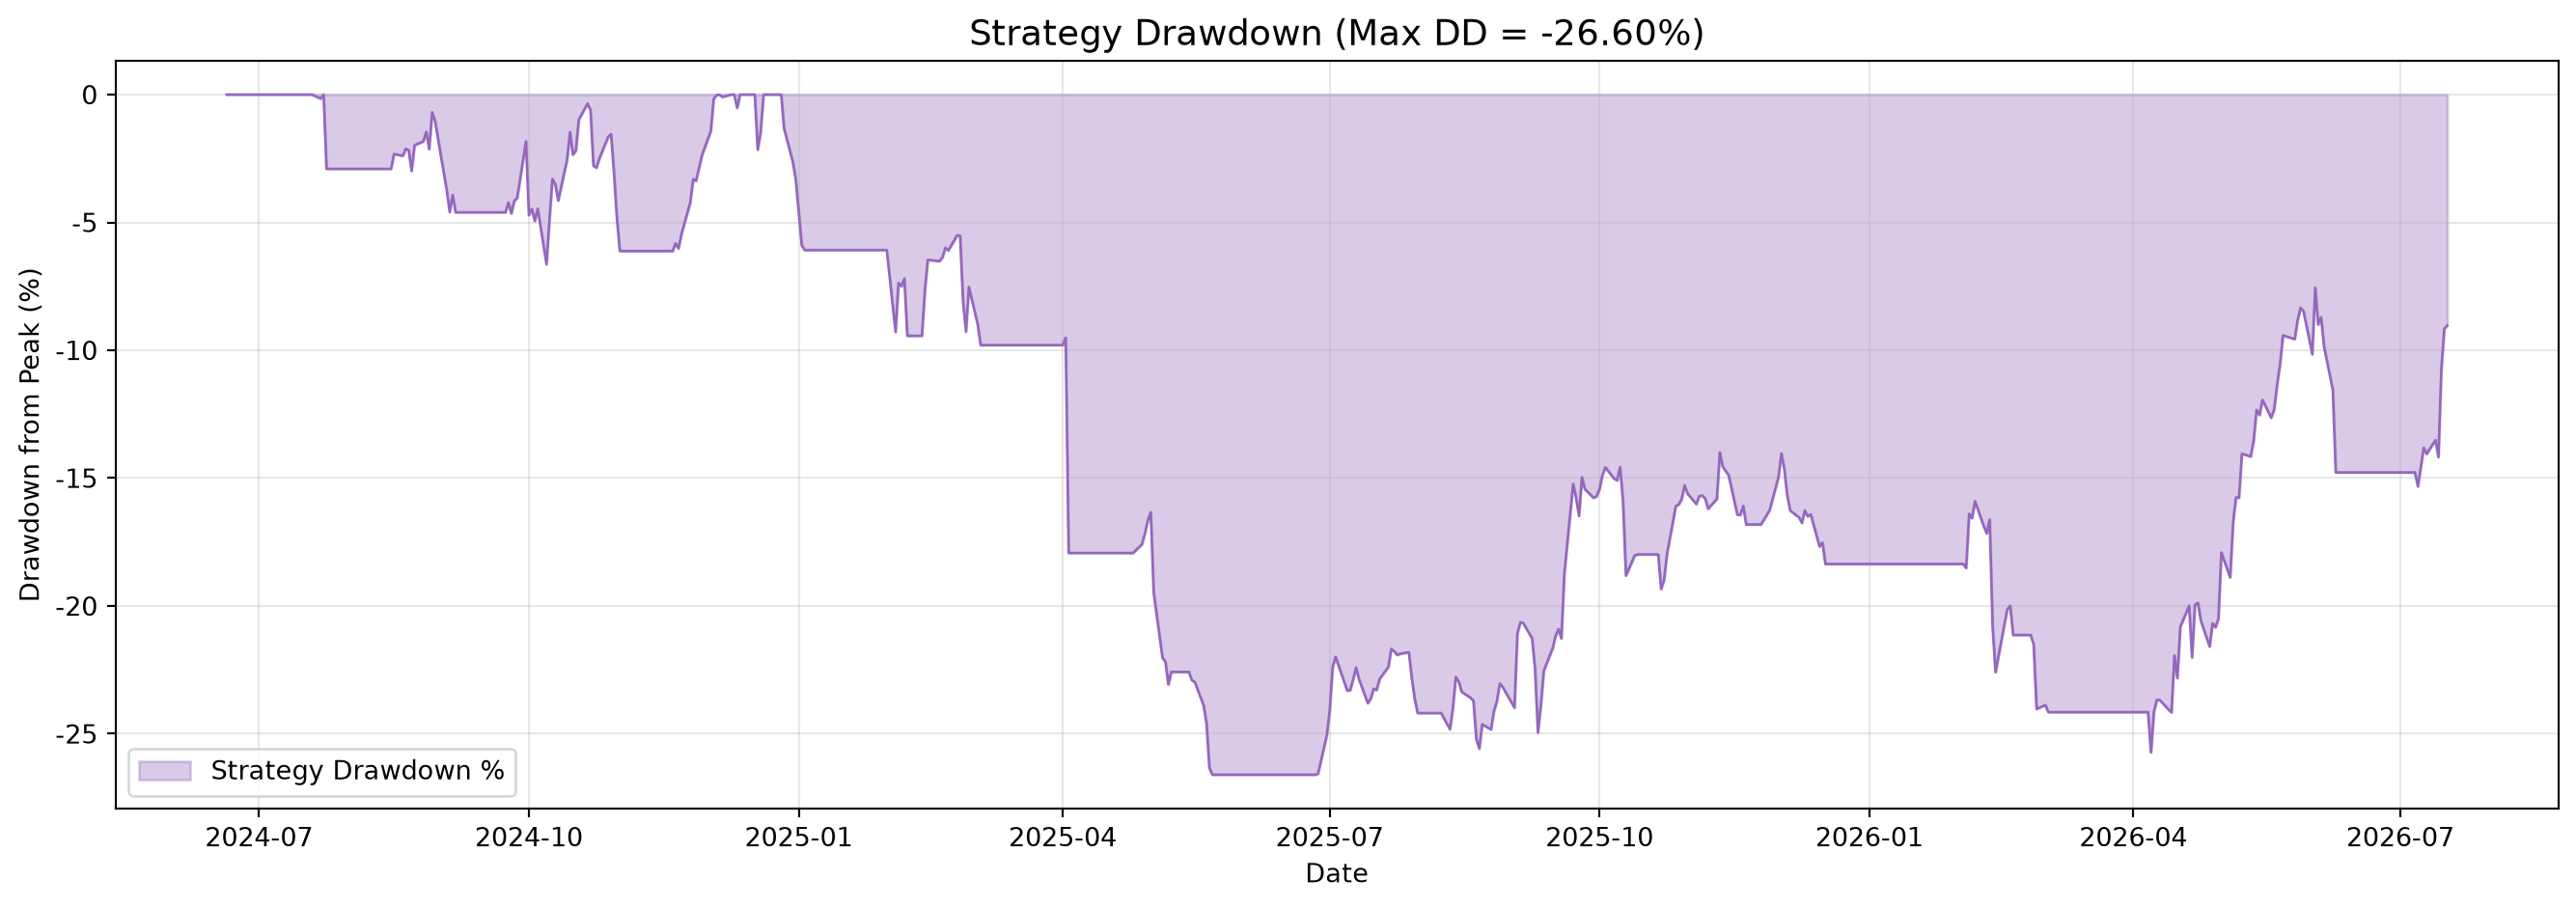

In [9]:
# ========== 最大回撤：从历史最高点最多跌了多少 ==========
def max_drawdown(nav_series):  # 定义最大回撤计算函数
    """输入净值序列，返回 (最大回撤比例, 每日回撤序列)。"""  # 字典字段
    peak = nav_series.cummax()           # 到每一天为止的历史最高净值
    drawdown = nav_series / peak - 1     # 当前净值相对峰值的跌幅
    return drawdown.min(), drawdown  # 返回最大回撤和回撤序列

mdd_strategy, dd_strategy = max_drawdown(df['nav_strategy'])  # 累计净值曲线
mdd_buyhold, dd_buyhold = max_drawdown(df['nav_buyhold'])  # 累计净值曲线

print('=== Maximum Drawdown (deepest drop from peak during sample period) ===')  # 打印分隔线或结论
print(f'  Dual MA Strategy: {mdd_strategy:.2%}')  # 格式化打印
print(f'  Buy & Hold ({TICKER}): {mdd_buyhold:.2%}')  # 格式化打印

fig, ax = plt.subplots(figsize=(14, 5))  # 创建子图
ax.fill_between(df.index, dd_strategy * 100, 0, alpha=0.35, color='tab:purple', label='Strategy Drawdown %')  # 在子图上填充区域
ax.plot(df.index, dd_strategy * 100, color='tab:purple', linewidth=1)  # 在子图上画折线
ax.set_title(f'Strategy Drawdown (Max DD = {mdd_strategy:.2%})', fontsize=14)  # 设置子图标题
ax.set_xlabel('Date')  # 设置子图横轴
ax.set_ylabel('Drawdown from Peak (%)')  # 设置子图纵轴
ax.legend()                                    # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

--- AAPL 回测指标 ---
Total Return (Strategy): -21.03%
Total Return (Buy&Hold): 55.46%
Total Return (Market): 40.10%
Win Rate: 36.84%
Max Drawdown (Strategy): -44.49%
Max Drawdown (Buy&Hold): -36.95%
Trades (Buy/Sell): 20
Hold Days: 277


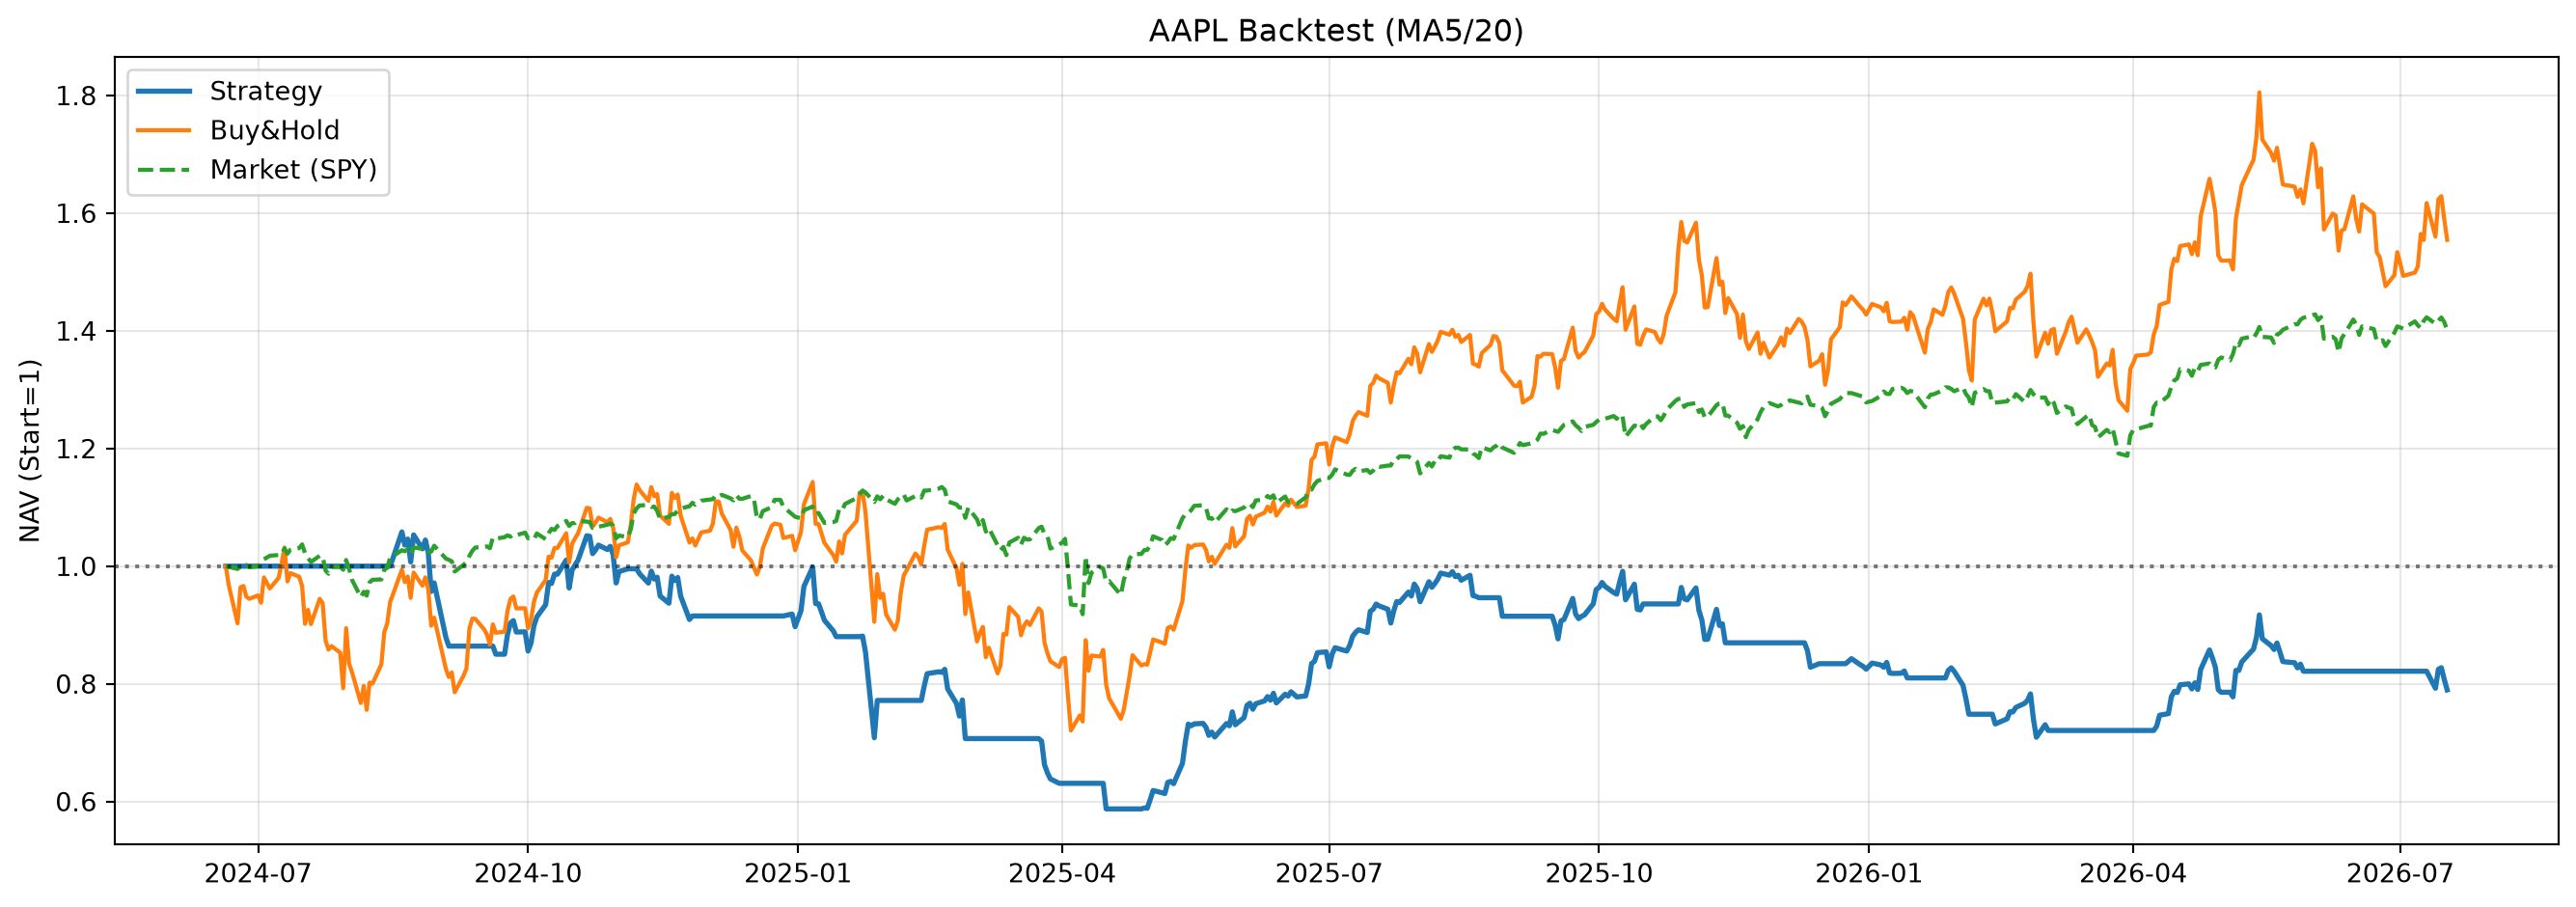

In [10]:
# ========== 策略回测工具（单只 / 多只股票） ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import akshare as ak
from datetime import datetime, timedelta

# ---------- 全局参数 ----------
SHORT_WIN = 5  # 短期均线窗口
LONG_WIN = 20  # 长期均线窗口
PERIOD = "2y"  # 回测区间（'1y', '2y', '3y' 等）
BENCHMARK = "SPY"  # 市场基准 ETF


# ---------- 核心策略函数 ----------
def backtest_ma_cross(
    ticker, period=PERIOD, short_win=SHORT_WIN, long_win=LONG_WIN, benchmark=BENCHMARK
):
    """
    对单只股票执行双均线策略回测，返回：
        df : 包含价格、信号、持仓、净值等的完整DataFrame
        metrics : 累计收益、胜率、最大回撤等指标
    """
    # 1. 解析时间区间
    if period.endswith("y"):
        days = int(period[:-1]) * 365
    elif period.endswith("m"):
        days = int(period[:-1]) * 30
    else:
        days = 365
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days + 30)

    # 2. 获取股票日线（akshare 美股接口）
    raw = ak.stock_us_daily(symbol=ticker, adjust="qfq")
    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw.set_index("date").sort_index()
    raw = raw[(raw.index >= start_date) & (raw.index <= end_date)]
    raw.columns = [col.capitalize() for col in raw.columns]
    df = raw[["Close"]].dropna().copy()

    # 3. 计算均线 & 信号
    df[f"MA{short_win}"] = df["Close"].rolling(short_win).mean()
    df[f"MA{long_win}"] = df["Close"].rolling(long_win).mean()
    df["signal"] = (df[f"MA{short_win}"] > df[f"MA{long_win}"]).astype(int)

    # 4. 信号延迟一天（避免未来信息）
    df["position"] = df["signal"].shift(1).fillna(0).astype(int)
    df["position_change"] = df["position"].diff().fillna(0)
    df["action"] = ""
    df.loc[df["position_change"] > 0, "action"] = "Buy"
    df.loc[df["position_change"] < 0, "action"] = "Sell"

    # 5. 计算策略日收益
    df["ret"] = df["Close"].pct_change().fillna(0)
    df["strategy_ret"] = df["position"] * df["ret"]

    # 6. 获取基准（SPY）数据（与股票同区间）
    bench_raw = ak.stock_us_daily(symbol=benchmark, adjust="qfq")
    bench_raw["date"] = pd.to_datetime(bench_raw["date"])
    bench_raw = bench_raw.set_index("date").sort_index()
    bench_raw = bench_raw[
        (bench_raw.index >= start_date) & (bench_raw.index <= end_date)
    ]
    bench_raw.columns = [col.capitalize() for col in bench_raw.columns]
    bench = bench_raw[["Close"]].rename(columns={"Close": f"{benchmark}_Close"})
    df = df.join(bench, how="inner")  # 对齐日期

    # 7. 计算基准收益和净值
    df["buyhold_ret"] = df["ret"]  # 买入持有（股票本身）
    df["market_ret"] = df[f"{benchmark}_Close"].pct_change().fillna(0)
    df["nav_strategy"] = (1 + df["strategy_ret"]).cumprod()
    df["nav_buyhold"] = (1 + df["buyhold_ret"]).cumprod()
    df["nav_market"] = (1 + df["market_ret"]).cumprod()

    # 8. 计算交易胜率
    wins, losses = 0, 0
    entry_price = None
    for date, row in df.iterrows():
        if row["action"] == "Buy":
            entry_price = row["Close"]
        elif row["action"] == "Sell" and entry_price is not None:
            pnl = row["Close"] / entry_price - 1
            if pnl > 0:
                wins += 1
            else:
                losses += 1
            entry_price = None
    win_rate = wins / (wins + losses) if (wins + losses) > 0 else np.nan

    # 9. 计算最大回撤
    def max_drawdown(nav):
        peak = nav.cummax()
        dd = nav / peak - 1
        return dd.min(), dd

    mdd_strategy, _ = max_drawdown(df["nav_strategy"])
    mdd_buyhold, _ = max_drawdown(df["nav_buyhold"])

    # 10. 汇总指标
    metrics = {
        "Total Return (Strategy)": df["nav_strategy"].iloc[-1] - 1,
        "Total Return (Buy&Hold)": df["nav_buyhold"].iloc[-1] - 1,
        "Total Return (Market)": df["nav_market"].iloc[-1] - 1,
        "Win Rate": win_rate,
        "Max Drawdown (Strategy)": mdd_strategy,
        "Max Drawdown (Buy&Hold)": mdd_buyhold,
        "Trades (Buy/Sell)": (df["action"] == "Buy").sum(),  # 买入次数
        "Hold Days": df["position"].sum(),
    }
    return df, metrics


# ========== 单只股票回测示例 ==========
df, metrics = backtest_ma_cross("NVDA", period="2y")
print("--- AAPL 回测指标 ---")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2%}" if abs(v) < 5 else f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")

# 绘制净值曲线（可选）
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["nav_strategy"], label="Strategy", linewidth=2)
ax.plot(df.index, df["nav_buyhold"], label="Buy&Hold", linewidth=1.6)
ax.plot(df.index, df["nav_market"], label="Market (SPY)", linestyle="--", linewidth=1.6)
ax.axhline(1, color="black", linestyle=":", alpha=0.5)
ax.set_title(f"AAPL Backtest (MA{SHORT_WIN}/{LONG_WIN})")
ax.set_ylabel("NAV (Start=1)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Backtesting NVDA for period 1y ...


Backtesting NVDA for period 5y ...


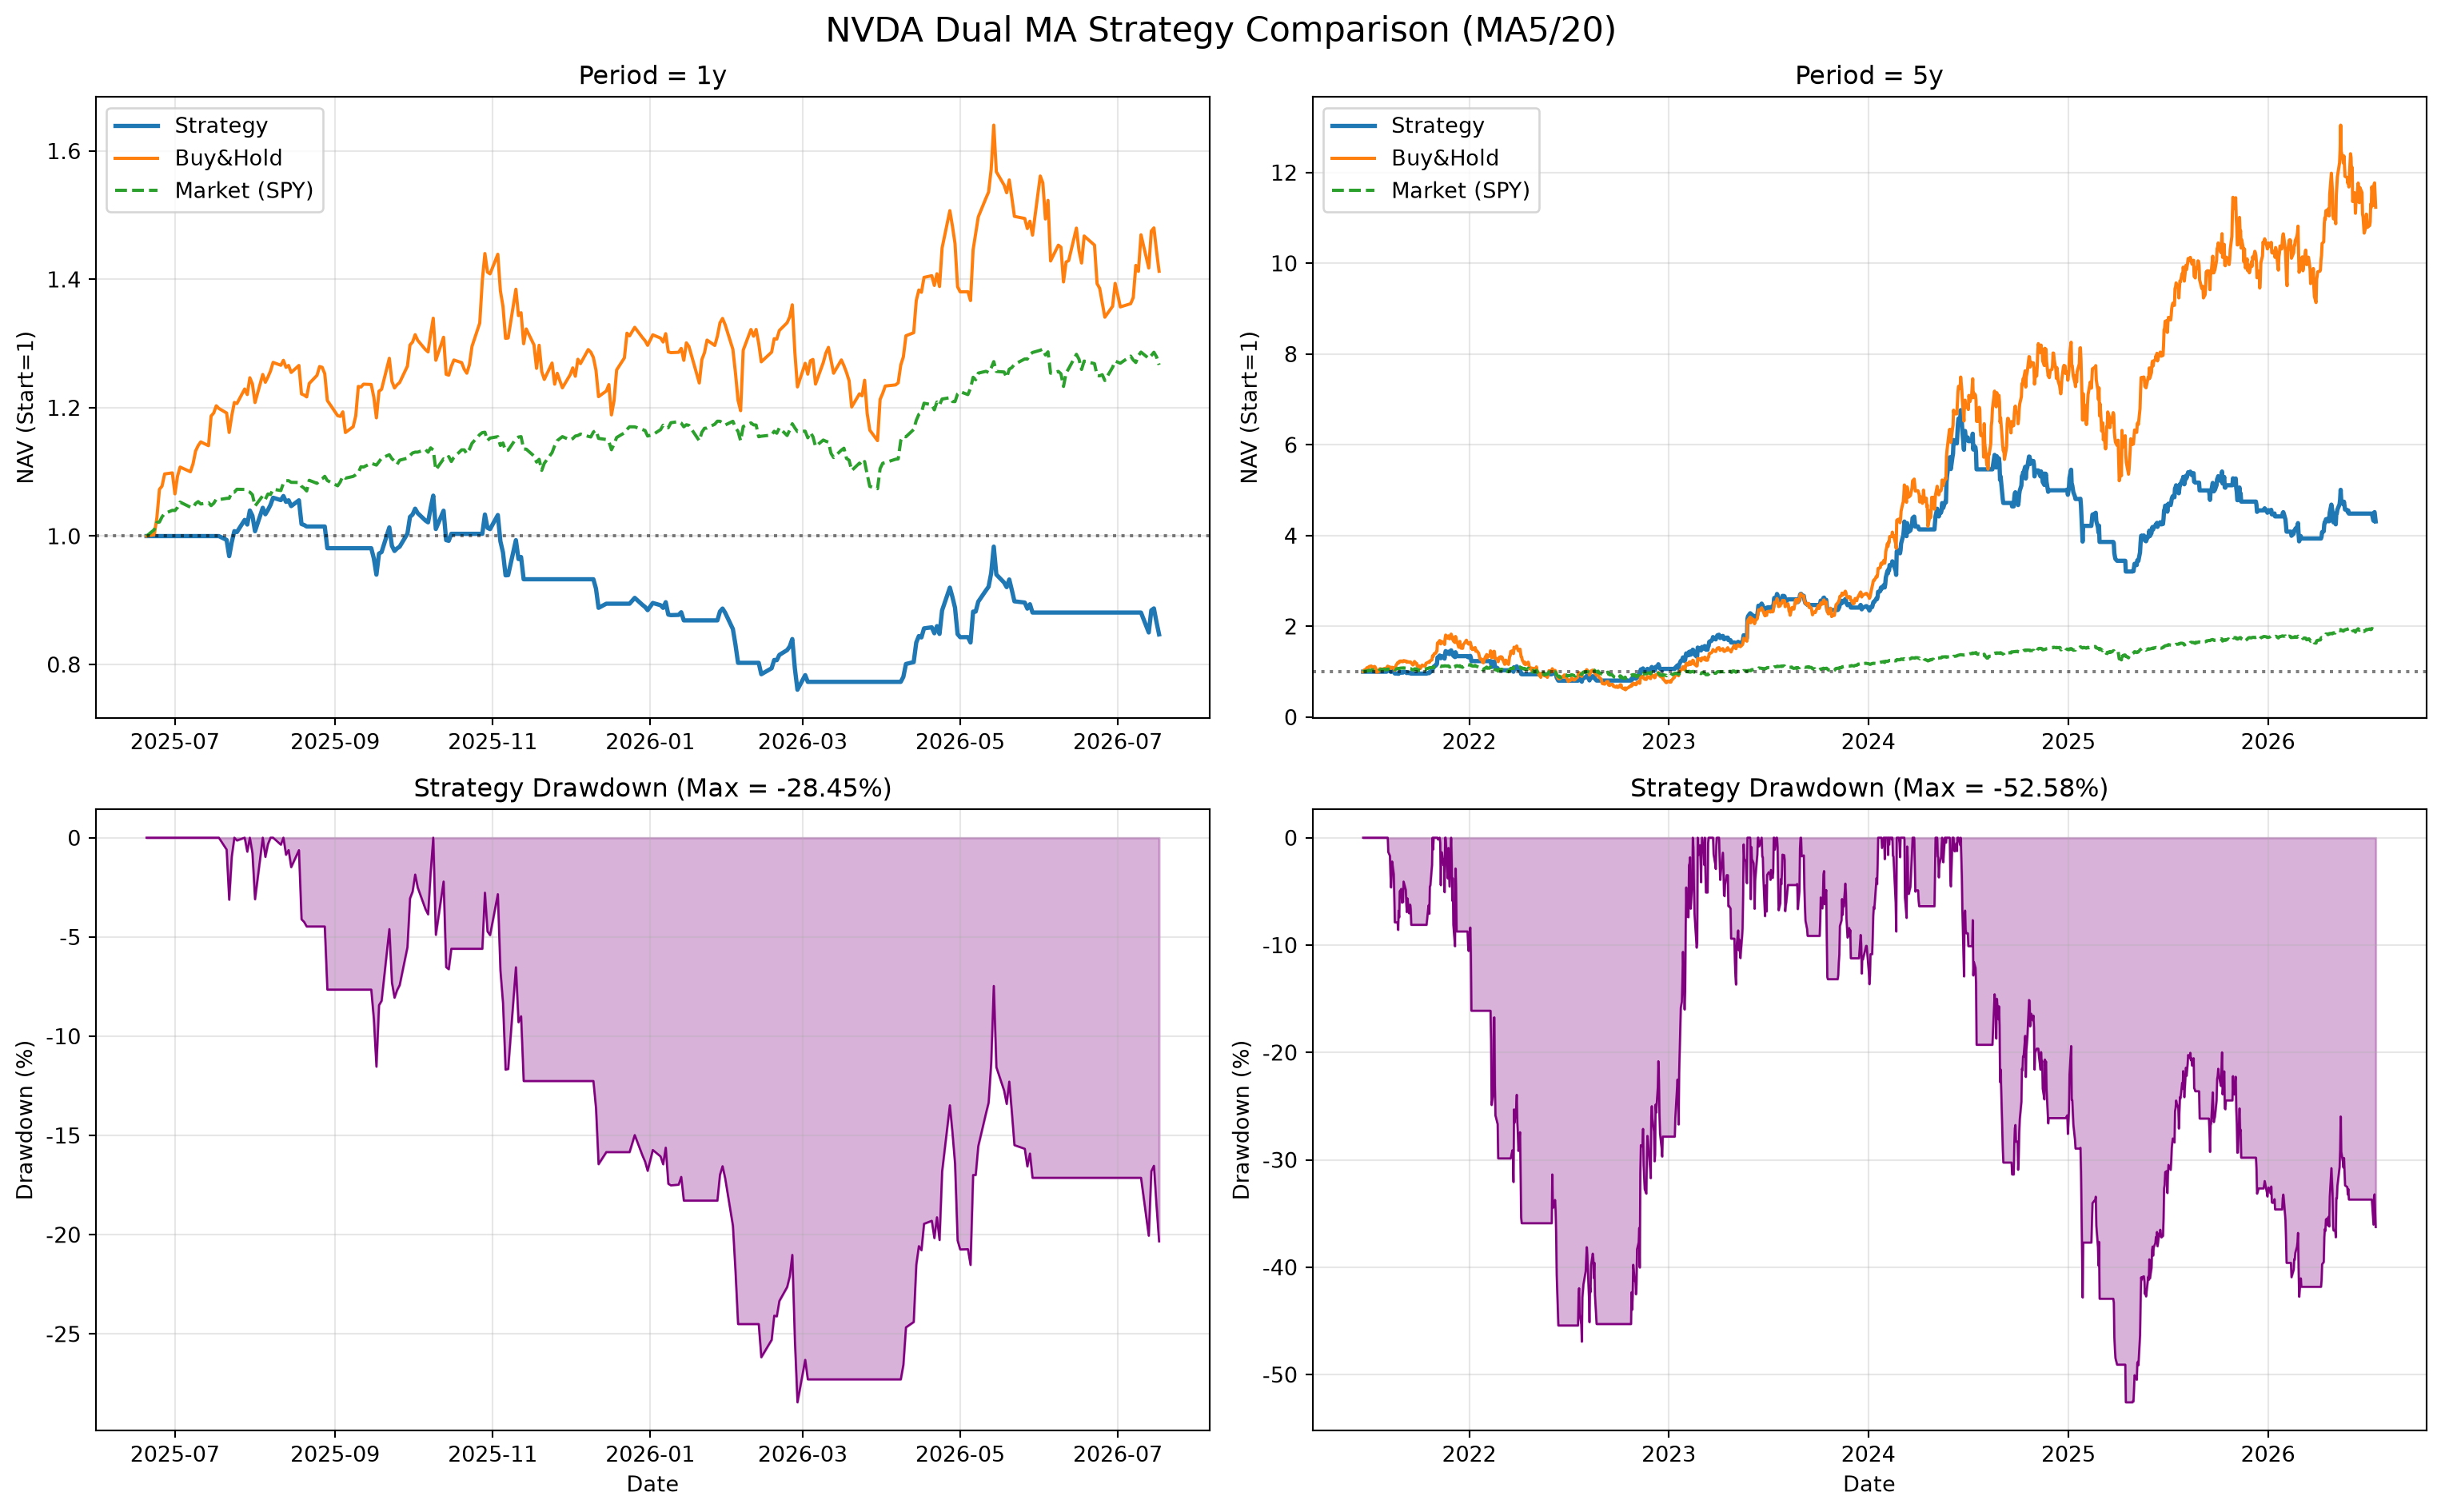


===== Key Metrics Comparison =====
   Total Return (Strategy) Total Return (Buy&Hold) Total Return (Market)  \
1y                 -15.31%                  41.26%                26.68%   
5y                 331.11%                1023.40%                92.17%   

   Win Rate Max Drawdown (Strategy) Max Drawdown (Buy&Hold) Trades (Buy/Sell)  \
1y   50.00%                 -28.45%                 -20.24%                11   
5y   41.03%                 -52.58%                 -67.06%                40   

   Hold Days  
1y       134  
5y       740  


In [11]:
# ========== 可视化对比：PERIOD='1y' vs '5y' ==========

TICKER = "NVDA"  # 分析的股票

# ---------- 分别跑 1y 和 5y ----------
periods = ["1y", "5y"]
dfs = {}
metrics_dict = {}

for p in periods:
    print(f"Backtesting {TICKER} for period {p} ...")
    df, met = backtest_ma_cross(TICKER, period=p)
    dfs[p] = df
    metrics_dict[p] = met

# ---------- 绘制对比图 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"{TICKER} Dual MA Strategy Comparison (MA{SHORT_WIN}/{LONG_WIN})", fontsize=16
)

# 第一行：净值曲线
for i, p in enumerate(periods):
    ax = axes[0, i]
    df = dfs[p]
    ax.plot(df.index, df["nav_strategy"], label="Strategy", linewidth=2)
    ax.plot(df.index, df["nav_buyhold"], label="Buy&Hold", linewidth=1.5)
    ax.plot(
        df.index, df["nav_market"], label="Market (SPY)", linestyle="--", linewidth=1.5
    )
    ax.axhline(1, color="black", linestyle=":", alpha=0.5)
    ax.set_title(f"Period = {p}")
    ax.set_ylabel("NAV (Start=1)")
    ax.legend()
    ax.grid(True, alpha=0.3)

# 第二行：回撤曲线（策略）
for i, p in enumerate(periods):
    ax = axes[1, i]
    df = dfs[p]
    # 计算回撤序列（策略）
    peak = df["nav_strategy"].cummax()
    dd = df["nav_strategy"] / peak - 1
    ax.fill_between(df.index, dd * 100, 0, alpha=0.3, color="purple")
    ax.plot(df.index, dd * 100, color="purple", linewidth=1)
    ax.set_title(f"Strategy Drawdown (Max = {dd.min():.2%})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown (%)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- 打印指标对比表格 ----------
print("\n===== Key Metrics Comparison =====")
df_compare = pd.DataFrame({"1y": metrics_dict["1y"], "5y": metrics_dict["5y"]}).T
# 格式化显示百分比
for col in df_compare.columns:
    if "Return" in col or "Drawdown" in col or "Win Rate" in col:
        df_compare[col] = df_compare[col].apply(lambda x: f"{x:.2%}")
    elif "Trades" in col or "Hold Days" in col:
        df_compare[col] = df_compare[col].apply(lambda x: f"{x:.0f}")
print(df_compare)

正在回测 AMD ...


正在回测 NVDA ...


正在回测 GOOGL ...


正在回测 TSLA ...


正在回测 QQQ ...


正在回测 SPY ...



--- 多股票策略表现对比 ---
       Strategy Ret  Win Rate  Max DD
AMD          2.5435    0.5000 -0.2968
NVDA        -0.2103    0.3684 -0.4449
GOOGL        0.8494    0.5385 -0.1628
TSLA         0.1507    0.4667 -0.5100
QQQ          0.1576    0.4500 -0.1321
SPY          0.1253    0.4706 -0.0860


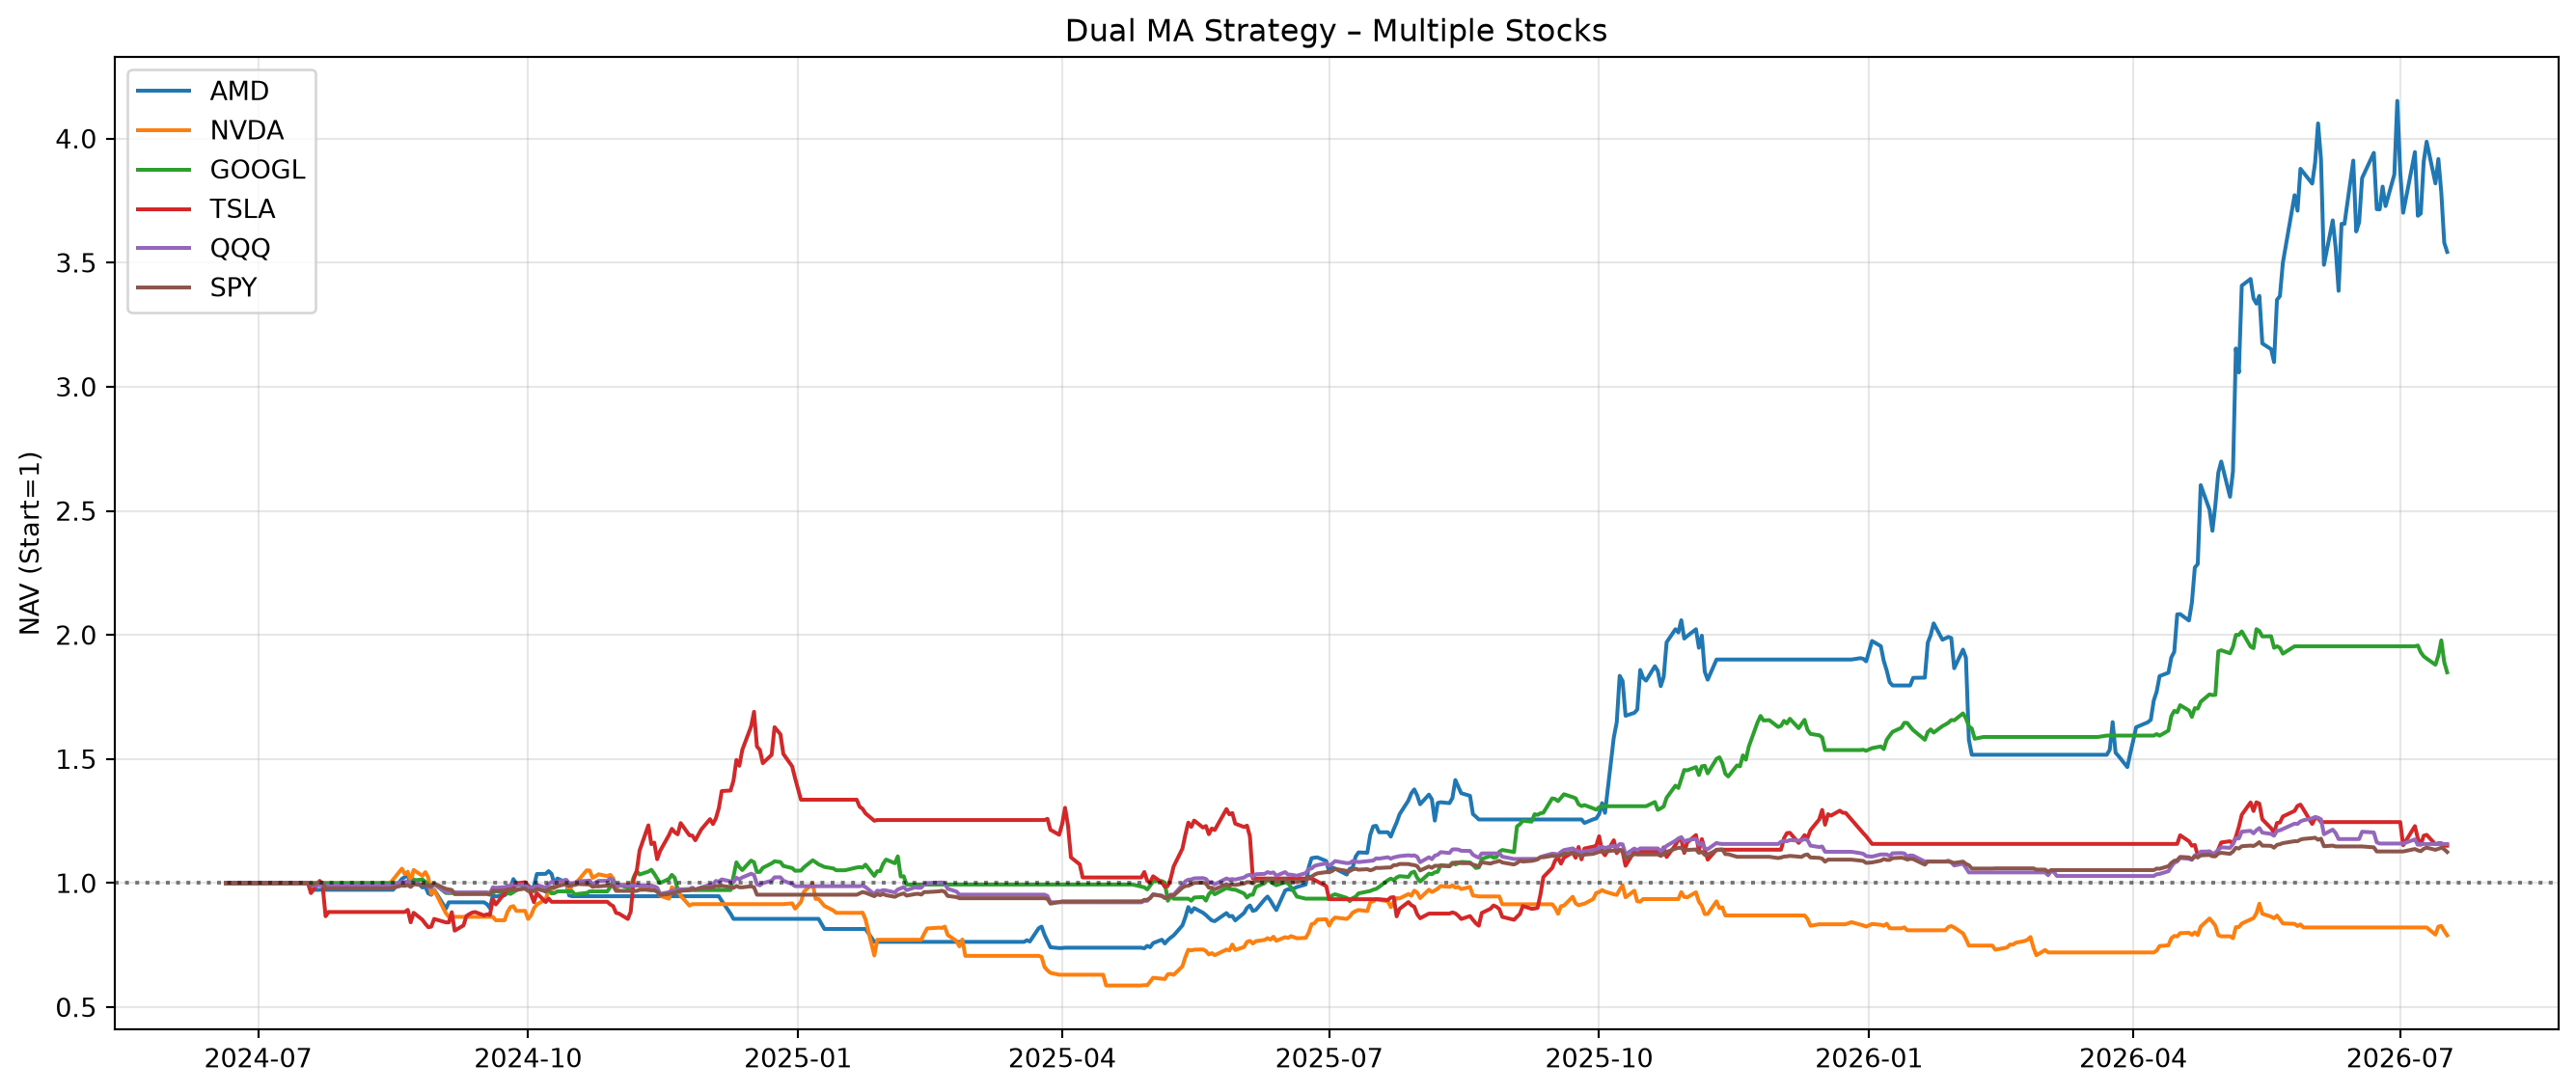

In [12]:
# ========== 多只股票批量回测 ==========
tickers = ["AMD", "NVDA", "GOOGL", "TSLA", "QQQ", "SPY"]
results = {}
for t in tickers:
    print(f"正在回测 {t} ...")
    _, metrics = backtest_ma_cross(t, period="2y")
    results[t] = metrics

# 输出对比表格
df_compare = pd.DataFrame(results).T  # 转置使股票为行
df_compare = df_compare[
    ["Total Return (Strategy)", "Win Rate", "Max Drawdown (Strategy)"]
]
df_compare.columns = ["Strategy Ret", "Win Rate", "Max DD"]
print("\n--- 多股票策略表现对比 ---")
print(df_compare.round(4))

# 绘制多股票净值曲线（同一画布）
fig, ax = plt.subplots(figsize=(14, 6))
for t in tickers:
    df_t, _ = backtest_ma_cross(t, period="2y")  # 重新执行获取净值（或缓存）
    ax.plot(df_t.index, df_t["nav_strategy"], label=t, linewidth=1.5)
ax.axhline(1, color="black", linestyle=":", alpha=0.5)
ax.set_title("Dual MA Strategy – Multiple Stocks")
ax.set_ylabel("NAV (Start=1)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()